In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [3]:
features = ["bedrooms", "bathrooms",  "floors", "sqft_living", "sqft_lot", "sqft_above", "house_age"]
target = "price"

In [14]:
def XGBoost(set_df, features, target, lambida, gama, min_split, min_leaf, cicles, rate):

  work_df = set_df[features].copy()
  work_df["target"] = set_df[target]

  work_df["hessian"] = 2
  work_df["pred_y"] = work_df["target"].mean()
  work_df["gradient"] = (-2)*(work_df["target"] - work_df["pred_y"])
  SQRES = abs(work_df["pred_y"] - work_df["target"]).mean()
  model = list()
  SQRES_list = [SQRES]
  for i in range(0, cicles):

    tree = node_function(work_df, features, gama, lambida, min_split, min_leaf)
    model.append(tree)
    weights = list()
    for s in work_df.index:
      weights.append(predict_func(tree, work_df.loc[s]))

    weights = np.array(weights)
    work_df["pred_y"] = work_df["pred_y"] + rate*weights
    work_df["gradient"] = (-2)*(work_df["target"] - work_df["pred_y"])
    SQRES_list.append(abs(work_df["pred_y"] - work_df["target"]).mean())

  return model, SQRES_list, work_df["target"].mean()

In [9]:
def node_function(data, features, gama, lambida, min_split, min_leaf):

    G = data["gradient"].sum()
    H = data["hessian"].sum()

    if len(data) <= min_split:
        return {"type": "leaf", "target_mean": data["target"].mean(), "weight": (-G)/(H + lambida)}

    top_feature = None
    top_limiar = None
    gain = -float("inf")
    K = int(len(features)*0.7)
    sorted = np.random.choice(features, size = K, replace = False)
    for i in sorted:
        temp_limiars = data[i].unique()
        if len(temp_limiars) <=20:
            np.sort(temp_limiars)
            limiars =  [(temp_limiars[s] + temp_limiars[s+1])/2 for s in range(0,len(temp_limiars)-1)]
            
        else:
            limiars = np.linspace(data[i].min(), data[i].max(), 20)

        for j in limiars:
            left_mask = data[i] <= j
            right_mask = data[i] > j
            left = data[left_mask]
            right = data[right_mask]

            if len(left) < min_leaf or len(right) < min_leaf:
                continue

            Gl = left["gradient"].sum()
            Hl = left["hessian"].sum()
            Gr = right["gradient"].sum()
            Hr = right["hessian"].sum()

            temp_gain = (((Gl**2)/(Hl + lambida)) + ((Gr**2)/(Hr + lambida)) - ((G**2)/(H + lambida)))

            if temp_gain > gain:
                gain = temp_gain
                top_feature = i
                top_limiar = j

    if gain <= gama:
        return {"type": "leaf", "target_mean": data["target"].mean(), "weight": (-G)/(H + lambida)}

    left = data[data[top_feature] <= top_limiar]
    right = data[data[top_feature] > top_limiar]

    left_child = node_function(left, features, gama, lambida, min_split, min_leaf)
    right_child = node_function(right, features, gama, lambida, min_split, min_leaf)

    return {"type": "node", "left_child": left_child, "right_child": right_child, "top_feature": top_feature, "treshold": top_limiar}

In [7]:
def predict_func(tree, sample):
  if tree["type"] == "leaf":
    return tree["weight"]

  feature = tree["top_feature"]
  treshold = tree["treshold"]

  if sample[feature] <= treshold:
    return predict_func(tree["left_child"], sample)

  if sample[feature] > treshold:
    return predict_func(tree["right_child"], sample)

In [ ]:
def result_func_XGBoos(model, basescore, sample):
    prev = basescore
    for i in model:
        adjust = predict_func(i, sample)
        prev = prev + 0.2*adjust
    
    return(prev)


In [22]:
json.dump({"model": modelo, "pregressao": progerssao, "base_score": base_score}, open("modelo_XGB.json", "w"))

In [16]:
modelo, progerssao, base_score = XGBoost(df,  features,  target,  1,  0,  5,  2,  20, 0.2)

In [23]:
teste_df = pd.read_csv("data/test_data.csv")
teste_df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_renovated,lat,long,hous_val_amt,trend,trend_sq,house_age,was_renovated
0,2414600126,2015-04-15,229500.0,3,1,1780,7470,1.0,0,0,...,1050,730,0,47.5123,-122.337,180100.0,11,121,55,False
1,1736800520,2015-04-03,662500.0,3,2,3560,9796,1.0,0,0,...,1860,1700,0,47.6007,-122.145,252600.0,11,121,50,False
2,7983200060,2015-04-24,230000.0,3,1,1250,9774,1.0,0,0,...,1250,0,0,47.3343,-122.306,166800.0,11,121,46,False
3,2799800710,2015-04-07,301000.0,3,2,2420,4750,2.0,0,0,...,2420,0,0,47.3663,-122.122,192000.0,11,121,12,False
4,2391600320,2015-04-20,480000.0,3,1,1040,5060,1.0,0,0,...,1040,0,0,47.5636,-122.394,286600.0,11,121,74,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2080,2122059216,2015-04-14,422000.0,4,2,2930,5973,2.0,0,0,...,2930,0,0,47.3846,-122.186,239850.0,11,121,7,False
2081,3528900770,2015-04-23,710200.0,4,3,1670,2642,2.0,0,0,...,1350,320,0,47.6397,-122.345,433500.0,11,121,7,False
2082,1931300412,2015-04-16,475000.0,3,2,1190,1200,3.0,0,0,...,1190,0,0,47.6542,-122.346,279200.0,11,121,7,False
2083,191100405,2015-04-21,1575000.0,4,3,3410,10125,2.0,0,0,...,3410,0,0,47.5653,-122.223,573900.0,11,121,8,False


In [29]:
prev_list = list()
for i in teste_df.index:
    prev = base_score
    for j in modelo:
        result = predict_func(j, teste_df.loc[i])
        prev = prev + 0.2*result
    prev_list.append(prev)


(array([  1.,   0.,   1.,   0.,   0.,   2.,   3.,   3.,   4.,   4.,   8.,
          7.,   7.,  13.,  29.,  56.,  88., 159., 217., 305., 271., 242.,
        199., 159.,  86.,  54.,  52.,  19.,  14.,  14.,  14.,  12.,   5.,
          5.,   1.,   4.,   4.,   3.,   1.,   2.,   2.,   0.,   2.,   3.,
          3.,   0.,   0.,   0.,   2.,   1.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-1071010.50900157, -1018107.28435696,  -965204.05971236,
         -912300.83506775,  -859397.61042315,  -806494.38577854,
         -753591.16113394,  -700687.93648933,  -647784.71184473,
         -594881.48720012,  -541978.26255552,  -489075.03791091,
         -436171.81326631,  -383268.5886217 ,  -330365.363

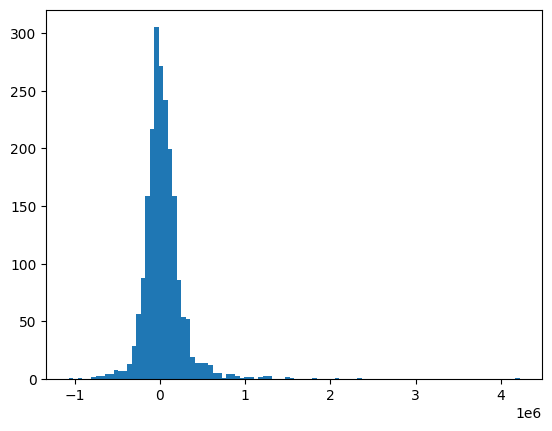

In [34]:
teste_df["prev"] = prev_list
teste_df["residuos"] = teste_df["price"] - teste_df["prev"]
plt.hist(teste_df["residuos"], bins = 100)

In [35]:
teste_df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_renovated,lat,long,hous_val_amt,trend,trend_sq,house_age,was_renovated,prev,residuos
0,2414600126,2015-04-15,229500.0,3,1,1780,7470,1.0,0,0,...,0,47.5123,-122.337,180100.0,11,121,55,False,2.945224e+05,-65022.367709
1,1736800520,2015-04-03,662500.0,3,2,3560,9796,1.0,0,0,...,0,47.6007,-122.145,252600.0,11,121,50,False,1.075950e+06,-413449.528824
2,7983200060,2015-04-24,230000.0,3,1,1250,9774,1.0,0,0,...,0,47.3343,-122.306,166800.0,11,121,46,False,2.511732e+05,-21173.165566
3,2799800710,2015-04-07,301000.0,3,2,2420,4750,2.0,0,0,...,0,47.3663,-122.122,192000.0,11,121,12,False,4.639688e+05,-162968.764050
4,2391600320,2015-04-20,480000.0,3,1,1040,5060,1.0,0,0,...,0,47.5636,-122.394,286600.0,11,121,74,False,3.155193e+05,164480.729311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2080,2122059216,2015-04-14,422000.0,4,2,2930,5973,2.0,0,0,...,0,47.3846,-122.186,239850.0,11,121,7,False,4.913268e+05,-69326.821362
2081,3528900770,2015-04-23,710200.0,4,3,1670,2642,2.0,0,0,...,0,47.6397,-122.345,433500.0,11,121,7,False,4.131567e+05,297043.334235
2082,1931300412,2015-04-16,475000.0,3,2,1190,1200,3.0,0,0,...,0,47.6542,-122.346,279200.0,11,121,7,False,4.155834e+05,59416.608709
2083,191100405,2015-04-21,1575000.0,4,3,3410,10125,2.0,0,0,...,0,47.5653,-122.223,573900.0,11,121,8,False,6.397541e+05,935245.946921
